# 🏗️ Heath-Jarrow-Morton (HJM) Model — Calibration & Simulation

This notebook calibrates a **multi-factor HJM model** to the Hungarian BIRS interest rate swap data.

## Framework

The HJM model describes the evolution of the *entire* forward rate curve:

$$df(t,T) = \alpha(t,T)\,dt + \sum_{k=1}^{K} \sigma_k(t,T)\,dW_k(t)$$

The key **no-arbitrage drift restriction** ties the drift to the volatility structure:

$$\alpha(t,T) = \sum_{k=1}^{K} \sigma_k(t,T) \int_t^T \sigma_k(t,s)\,ds$$

This means the model is fully specified once we know the **volatility functions** $\sigma_k(t,T)$.

### Calibration Strategy
1. Bootstrap zero rates and extract forward rates from the BIRS swap curve
2. Compute daily forward rate changes
3. **PCA** to identify the dominant volatility factors
4. Fit parametric volatility functions to the PCA loadings
5. Apply the HJM drift restriction
6. Monte Carlo simulation of the forward curve

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Load BIRS data
df = pd.read_pickle('data/birs_flat.pkl')
df['date of fixing'] = pd.to_datetime(df['date of fixing'])
df = df.sort_values('date of fixing').reset_index(drop=True)

tenor_cols = [c for c in df.columns if 'years' in c]
tenor_cols.sort(key=lambda x: int(x.split()[0]))
swap_maturities = np.array([int(c.split()[0]) for c in tenor_cols])

print(f"BIRS data: {len(df):,} days, {df['date of fixing'].min().date()} → {df['date of fixing'].max().date()}")
print(f"Swap tenors: {swap_maturities} years")

BIRS data: 4,940 days, 2006-11-15 → 2026-06-08
Swap tenors: [ 2  3  4  5  6  7  8  9 10 12 15 20] years


## 1. Bootstrapping: Swap Rates → Zero Rates → Forward Rates

BIRS are **swap rates** (par yields). To build an HJM model we need **instantaneous forward rates**.

**Pipeline**: Swap Rates → *(bootstrap)* → Discount Factors → Zero Rates → Forward Rates

We assume annual fixed-leg payments for the IRS.

In [2]:
def bootstrap_zero_rates(swap_rates, tenors):
    """
    Bootstrap zero-coupon rates from swap rates.
    Assumes annual compounding / annual coupon frequency.
    
    swap_rates: array of par swap rates (in %)
    tenors: array of maturities (years)
    Returns: zero rates at an annual grid from year 1 to max(tenors)
    """
    # First interpolate swap rates to a full annual grid
    max_T = int(tenors.max())
    annual_grid = np.arange(1, max_T + 1, dtype=float)
    
    # Use cubic spline to fill in missing tenors (e.g. 11Y, 13Y, 14Y)
    # Extrapolate flat for 1Y (from 2Y)
    cs = CubicSpline(tenors, swap_rates, bc_type='natural')
    swap_annual = cs(annual_grid)
    # Clamp 1Y to be reasonable (extrapolated from short end)
    
    # Bootstrap discount factors
    discount_factors = np.zeros(max_T)
    for i, T in enumerate(annual_grid):
        T_int = int(T)
        S = swap_annual[i] / 100.0  # convert from % to decimal
        if T_int == 1:
            discount_factors[i] = 1.0 / (1.0 + S)
        else:
            sum_prev = np.sum(discount_factors[:i])
            discount_factors[i] = (1.0 - S * sum_prev) / (1.0 + S)
    
    # Convert to continuously compounded zero rates
    zero_rates = np.zeros(max_T)
    for i, T in enumerate(annual_grid):
        if discount_factors[i] > 0:
            zero_rates[i] = -np.log(discount_factors[i]) / T * 100  # in %
        else:
            zero_rates[i] = np.nan
    
    return annual_grid, zero_rates, discount_factors


def compute_forward_rates(annual_grid, zero_rates):
    """
    Compute instantaneous forward rates from zero rates.
    f(0,T) ≈ z(T) + T * dz/dT  (continuous approximation)
    For discrete: f(T_i, T_{i+1}) = [z(T_{i+1})*T_{i+1} - z(T_i)*T_i] / (T_{i+1} - T_i)
    """
    T = annual_grid
    zT = zero_rates * T / 100.0  # z(T)*T in decimal
    
    # Forward rate between consecutive annual points
    fwd = np.zeros(len(T))
    fwd[0] = zero_rates[0]  # f(0,1) ≈ z(1)
    for i in range(1, len(T)):
        dT = T[i] - T[i-1]
        fwd[i] = (zT[i] - zT[i-1]) / dT * 100  # in %
    
    return fwd


# Test on the latest day
latest = df.iloc[-1]
swap_rates = latest[tenor_cols].values.astype(float)
valid = ~np.isnan(swap_rates)
sr = swap_rates[valid]
tn = swap_maturities[valid].astype(float)

grid, zeros, disc = bootstrap_zero_rates(sr, tn)
fwds = compute_forward_rates(grid, zeros)

print("Latest day bootstrap results:")
print(f"{'Tenor':>6s} {'Swap%':>8s} {'Zero%':>8s} {'Disc':>8s} {'Fwd%':>8s}")
print("-" * 42)
for i in range(len(grid)):
    T = int(grid[i])
    # Find matching swap rate if available
    swap_str = ""
    if T in swap_maturities:
        idx = list(swap_maturities).index(T)
        if not np.isnan(swap_rates[idx]):
            swap_str = f"{swap_rates[idx]:.3f}"
    print(f"{T:>5d}Y {swap_str:>8s} {zeros[i]:>8.3f} {disc[i]:>8.5f} {fwds[i]:>8.3f}")

Latest day bootstrap results:
 Tenor    Swap%    Zero%     Disc     Fwd%
------------------------------------------
    1Y             5.600  0.94554    5.600
    2Y    5.620    5.464  0.89648    5.328
    3Y    5.480    5.325  0.85235    5.048
    4Y    5.380    5.225  0.81139    4.925
    5Y    5.310    5.154  0.77281    4.872
    6Y    5.270    5.115  0.73575    4.915
    7Y    5.250    5.095  0.70000    4.981
    8Y    5.230    5.075  0.66629    4.935
    9Y    5.220    5.066  0.63385    4.993
   10Y    5.220    5.068  0.60240    5.088
   11Y             5.070  0.57251    5.089
   12Y    5.220    5.072  0.54411    5.087
   13Y             5.076  0.51695    5.122
   14Y             5.081  0.49095    5.159
   15Y    5.230    5.088  0.46615    5.185
   16Y             5.095  0.44254    5.196
   17Y             5.102  0.42010    5.205
   18Y             5.108  0.39876    5.214
   19Y             5.114  0.37846    5.224
   20Y    5.250    5.120  0.35916    5.236


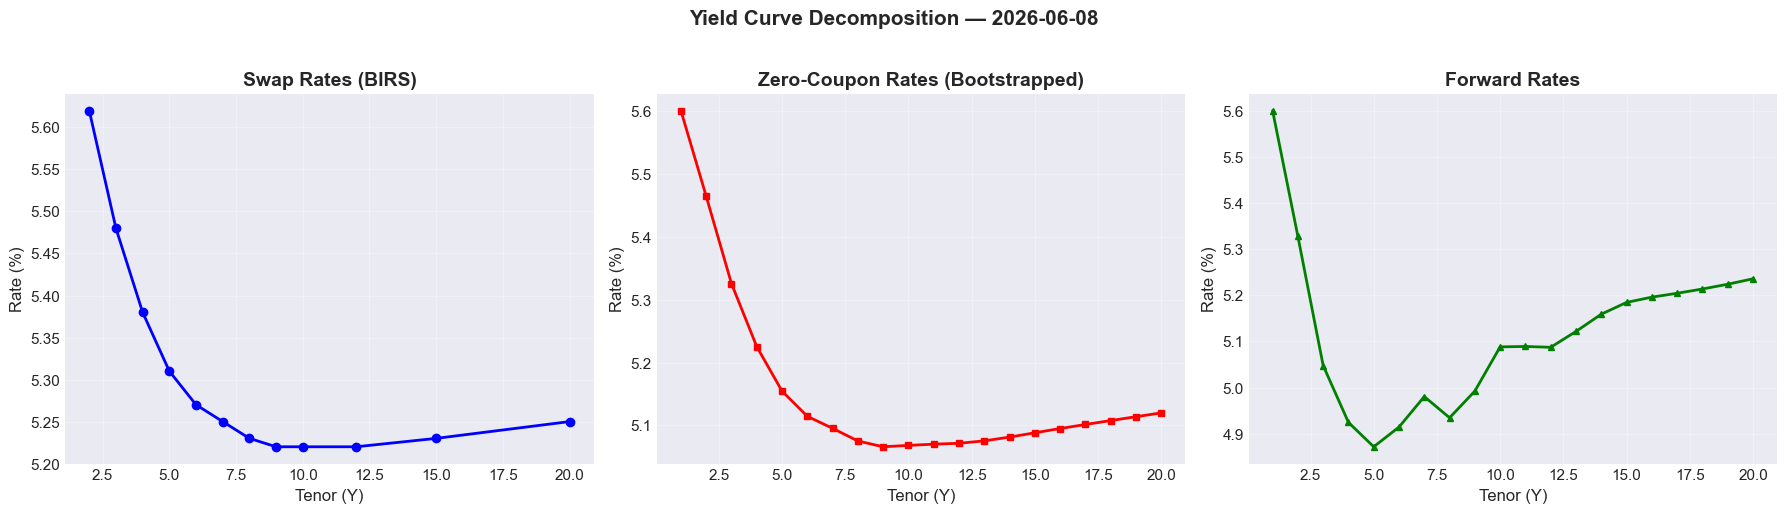

In [3]:
# Visualize the transformation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Swap rates
axes[0].plot(tn, sr, 'bo-', markersize=6, linewidth=2)
axes[0].set_title('Swap Rates (BIRS)', fontweight='bold')
axes[0].set_xlabel('Tenor (Y)')
axes[0].set_ylabel('Rate (%)')
axes[0].grid(True, alpha=0.3)

# Zero rates
axes[1].plot(grid, zeros, 'rs-', markersize=4, linewidth=2)
axes[1].set_title('Zero-Coupon Rates (Bootstrapped)', fontweight='bold')
axes[1].set_xlabel('Tenor (Y)')
axes[1].set_ylabel('Rate (%)')
axes[1].grid(True, alpha=0.3)

# Forward rates
axes[2].plot(grid, fwds, 'g^-', markersize=4, linewidth=2)
axes[2].set_title('Forward Rates', fontweight='bold')
axes[2].set_xlabel('Tenor (Y)')
axes[2].set_ylabel('Rate (%)')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Yield Curve Decomposition — {latest["date of fixing"].strftime("%Y-%m-%d")}',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 2. Forward Rate Surface

Extract the daily forward rate curve for the entire history to build the forward rate surface $f(t, T)$.

In [4]:
# Bootstrap forward rates for every trading day
# Use the most recent 5 years for calibration (more stable, manageable)
cutoff = df['date of fixing'].max() - pd.DateOffset(years=5)
df_calib = df[df['date of fixing'] >= cutoff].copy().reset_index(drop=True)
print(f"Calibration window: {df_calib['date of fixing'].min().date()} → "
      f"{df_calib['date of fixing'].max().date()} ({len(df_calib)} days)")

# Determine common tenor grid: use max tenor present in ALL calibration days
max_tenor = 20  # target
annual_grid_target = np.arange(1, max_tenor + 1, dtype=float)

forward_rates_list = []
dates_list = []
skipped = 0

for i in range(len(df_calib)):
    row = df_calib.iloc[i]
    sr = row[tenor_cols].values.astype(float)
    valid = ~np.isnan(sr)
    
    if valid.sum() < 5:
        skipped += 1
        continue
    
    tenors_v = swap_maturities[valid].astype(float)
    sr_v = sr[valid]
    
    try:
        max_T_avail = int(tenors_v.max())
        grid, zeros, disc = bootstrap_zero_rates(sr_v, tenors_v)
        fwds = compute_forward_rates(grid, zeros)
        
        # Pad or trim to consistent grid
        fwd_row = np.full(max_tenor, np.nan)
        for j, T in enumerate(grid):
            idx = int(T) - 1
            if idx < max_tenor:
                fwd_row[idx] = fwds[j]
        
        forward_rates_list.append(fwd_row)
        dates_list.append(row['date of fixing'])
    except Exception:
        skipped += 1
        continue

fwd_matrix = np.array(forward_rates_list)
fwd_dates = np.array(dates_list)
print(f"Forward rate matrix: {fwd_matrix.shape} (days × tenors)")
print(f"Skipped {skipped} days due to insufficient data")

# Check for NaN columns
nan_pct = np.isnan(fwd_matrix).mean(axis=0) * 100
print(f"\nNaN % by tenor:")
for t in range(max_tenor):
    print(f"  {t+1}Y: {nan_pct[t]:.1f}%")

Calibration window: 2021-06-08 → 2026-06-08 (1263 days)
Forward rate matrix: (1263, 20) (days × tenors)
Skipped 0 days due to insufficient data

NaN % by tenor:
  1Y: 0.0%
  2Y: 0.0%
  3Y: 0.0%
  4Y: 0.0%
  5Y: 0.0%
  6Y: 0.0%
  7Y: 0.0%
  8Y: 0.0%
  9Y: 0.0%
  10Y: 0.0%
  11Y: 0.0%
  12Y: 0.0%
  13Y: 0.0%
  14Y: 0.0%
  15Y: 0.0%
  16Y: 0.0%
  17Y: 0.0%
  18Y: 0.0%
  19Y: 0.0%
  20Y: 0.0%


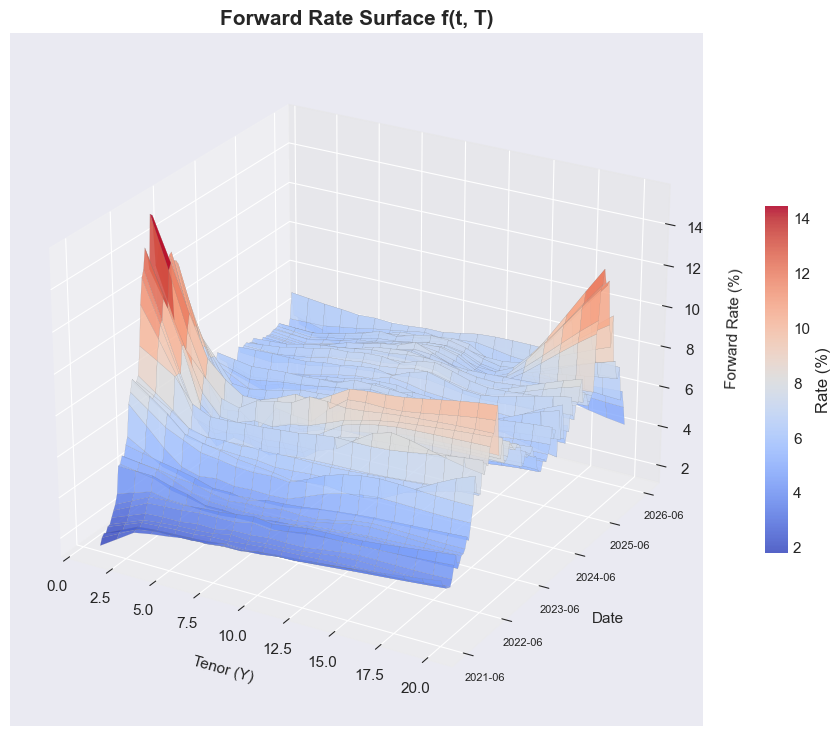

In [5]:
# Forward rate surface plot
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111, projection='3d')

# Subsample for visibility
step = max(1, len(fwd_dates) // 100)
dates_num = mdates.date2num(fwd_dates[::step])
tenors_grid = annual_grid_target

X, Y = np.meshgrid(tenors_grid, dates_num)
Z = fwd_matrix[::step, :len(tenors_grid)]

# Replace NaN with interpolated values for plotting
for row in range(Z.shape[0]):
    mask = ~np.isnan(Z[row])
    if mask.sum() >= 2:
        Z[row] = np.interp(tenors_grid, tenors_grid[mask], Z[row][mask])

surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.85,
                       rstride=1, cstride=1, linewidth=0.1, edgecolor='gray')

ax.set_xlabel('Tenor (Y)', fontsize=11, labelpad=10)
ax.set_ylabel('Date', fontsize=11, labelpad=10)
ax.set_zlabel('Forward Rate (%)', fontsize=11, labelpad=10)
ax.set_title('Forward Rate Surface f(t, T)', fontweight='bold', fontsize=15)

# Format y-axis dates
y_ticks = np.linspace(dates_num[0], dates_num[-1], 6)
ax.set_yticks(y_ticks)
ax.set_yticklabels([mdates.num2date(d).strftime('%Y-%m') for d in y_ticks], fontsize=8)

fig.colorbar(surf, shrink=0.5, aspect=15, label='Rate (%)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

## 3. Daily Forward Rate Changes

The HJM model is calibrated to the **changes** in forward rates: $\Delta f(t, T_j) = f(t+1, T_j) - f(t, T_j)$.

We analyze these changes to extract the volatility structure.

In [6]:
# Compute daily changes
# Use tenors 2Y-20Y (skip 1Y which can be noisy from extrapolation)
use_tenors = np.arange(1, max_tenor)  # indices 1..19 → tenors 2Y..20Y
tenor_labels = [f'{t+1}Y' for t in use_tenors]

fwd_changes = np.diff(fwd_matrix[:, use_tenors], axis=0)

# Remove rows with any NaN
valid_rows = ~np.any(np.isnan(fwd_changes), axis=1)
fwd_changes_clean = fwd_changes[valid_rows]
dates_changes = fwd_dates[1:][valid_rows]

print(f"Forward rate changes matrix: {fwd_changes_clean.shape}")
print(f"Tenors used: {tenor_labels}")

# Summary statistics
print(f"\nDaily change statistics (basis points):")
stats = pd.DataFrame({
    'Mean': np.mean(fwd_changes_clean, axis=0) * 100,
    'Std': np.std(fwd_changes_clean, axis=0) * 100,
    'Min': np.min(fwd_changes_clean, axis=0) * 100,
    'Max': np.max(fwd_changes_clean, axis=0) * 100,
    'Skew': pd.DataFrame(fwd_changes_clean).skew().values,
    'Kurt': pd.DataFrame(fwd_changes_clean).kurtosis().values,
}, index=tenor_labels)
print(stats.round(2).to_string())

Forward rate changes matrix: (1262, 19)
Tenors used: ['2Y', '3Y', '4Y', '5Y', '6Y', '7Y', '8Y', '9Y', '10Y', '11Y', '12Y', '13Y', '14Y', '15Y', '16Y', '17Y', '18Y', '19Y', '20Y']

Daily change statistics (basis points):
     Mean    Std     Min     Max  Skew   Kurt
2Y   0.27  12.83 -109.85   73.34 -0.46   9.64
3Y   0.20  14.41 -135.10   79.36 -0.74  10.98
4Y   0.18  14.25 -127.69   77.37 -0.40   8.85
5Y   0.16  14.97 -141.53   79.68 -0.55   9.31
6Y   0.16  13.05  -86.25   62.01 -0.52   5.37
7Y   0.16  14.89 -152.29  102.20 -0.71  14.41
8Y   0.15  13.87 -117.37   62.76 -0.67   6.15
9Y   0.15  15.09 -120.30   86.75 -0.12   6.08
10Y  0.15  17.61 -161.44   93.08 -0.71   8.67
11Y  0.14  14.05 -123.24   72.46 -0.67   8.10
12Y  0.13  16.58  -88.27  100.88  0.10   2.95
13Y  0.13  13.82 -101.51   64.76 -0.26   4.61
14Y  0.13  16.32 -121.88   71.29 -0.31   4.47
15Y  0.12  18.18 -132.13   83.34 -0.33   3.94
16Y  0.11  16.83 -129.43   76.91 -0.37   5.03
17Y  0.11  18.99 -123.52  122.50 -0.25   7.1

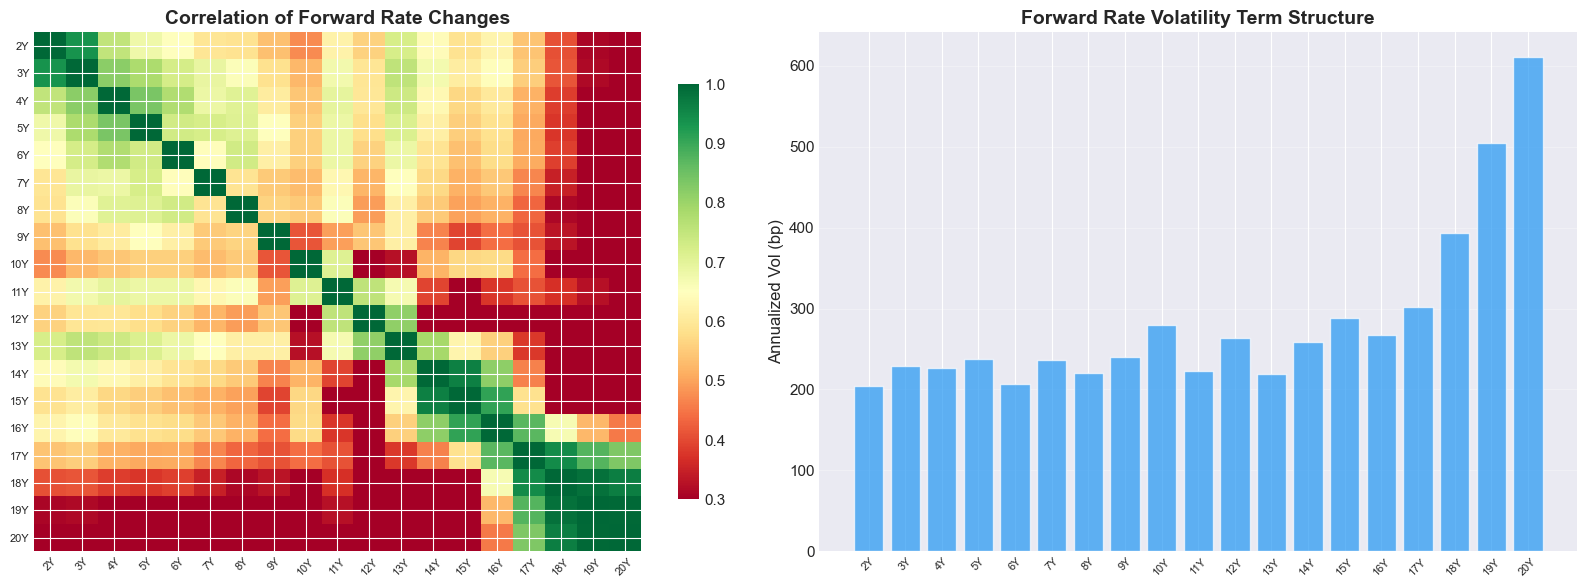

In [7]:
# Correlation matrix of forward rate changes
corr = np.corrcoef(fwd_changes_clean.T)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
im = axes[0].imshow(corr, cmap='RdYlGn', vmin=0.3, vmax=1.0, aspect='auto')
axes[0].set_xticks(range(len(tenor_labels)))
axes[0].set_xticklabels(tenor_labels, rotation=45, fontsize=8)
axes[0].set_yticks(range(len(tenor_labels)))
axes[0].set_yticklabels(tenor_labels, fontsize=8)
axes[0].set_title('Correlation of Forward Rate Changes', fontweight='bold')
fig.colorbar(im, ax=axes[0], shrink=0.8)

# Volatility term structure
vol = np.std(fwd_changes_clean, axis=0) * 100 * np.sqrt(252)  # annualized, in bp
axes[1].bar(range(len(tenor_labels)), vol, color='#2196F3', alpha=0.7, edgecolor='white')
axes[1].set_xticks(range(len(tenor_labels)))
axes[1].set_xticklabels(tenor_labels, rotation=45, fontsize=8)
axes[1].set_title('Forward Rate Volatility Term Structure', fontweight='bold')
axes[1].set_ylabel('Annualized Vol (bp)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Principal Component Analysis — Volatility Factors

PCA on forward rate changes extracts the dominant **volatility eigenvectors** that define the HJM model.

The $k$-th PCA loading vector directly gives us the volatility function $\sigma_k(T)$, scaled by the square root of the eigenvalue.

In [8]:
# PCA on forward rate changes
# Standardize? No — we want the actual covariance structure
cov_matrix = np.cov(fwd_changes_clean.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort by descending eigenvalue
idx_sort = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx_sort]
eigenvectors = eigenvectors[:, idx_sort]

# Variance explained
total_var = eigenvalues.sum()
var_explained = eigenvalues / total_var * 100
cum_var = np.cumsum(var_explained)

print("PCA Results — Variance Explained:")
print(f"{'PC':>4s} {'Eigenvalue':>12s} {'Var%':>8s} {'Cumul%':>8s}")
print("-" * 36)
for i in range(min(10, len(eigenvalues))):
    print(f"  {i+1:>2d} {eigenvalues[i]:>12.6f} {var_explained[i]:>7.2f}% {cum_var[i]:>7.2f}%")

# How many factors?
n_factors_90 = np.searchsorted(cum_var, 90) + 1
n_factors_95 = np.searchsorted(cum_var, 95) + 1
n_factors_99 = np.searchsorted(cum_var, 99) + 1
print(f"\nFactors needed for 90%: {n_factors_90}")
print(f"Factors needed for 95%: {n_factors_95}")
print(f"Factors needed for 99%: {n_factors_99}")

PCA Results — Variance Explained:
  PC   Eigenvalue     Var%   Cumul%
------------------------------------
   1     0.389336   56.13%   56.13%
   2     0.174683   25.18%   81.32%
   3     0.050788    7.32%   88.64%
   4     0.024831    3.58%   92.22%
   5     0.012526    1.81%   94.03%
   6     0.009775    1.41%   95.43%
   7     0.009045    1.30%   96.74%
   8     0.008456    1.22%   97.96%
   9     0.005586    0.81%   98.76%
  10     0.004615    0.67%   99.43%

Factors needed for 90%: 4
Factors needed for 95%: 6
Factors needed for 99%: 10


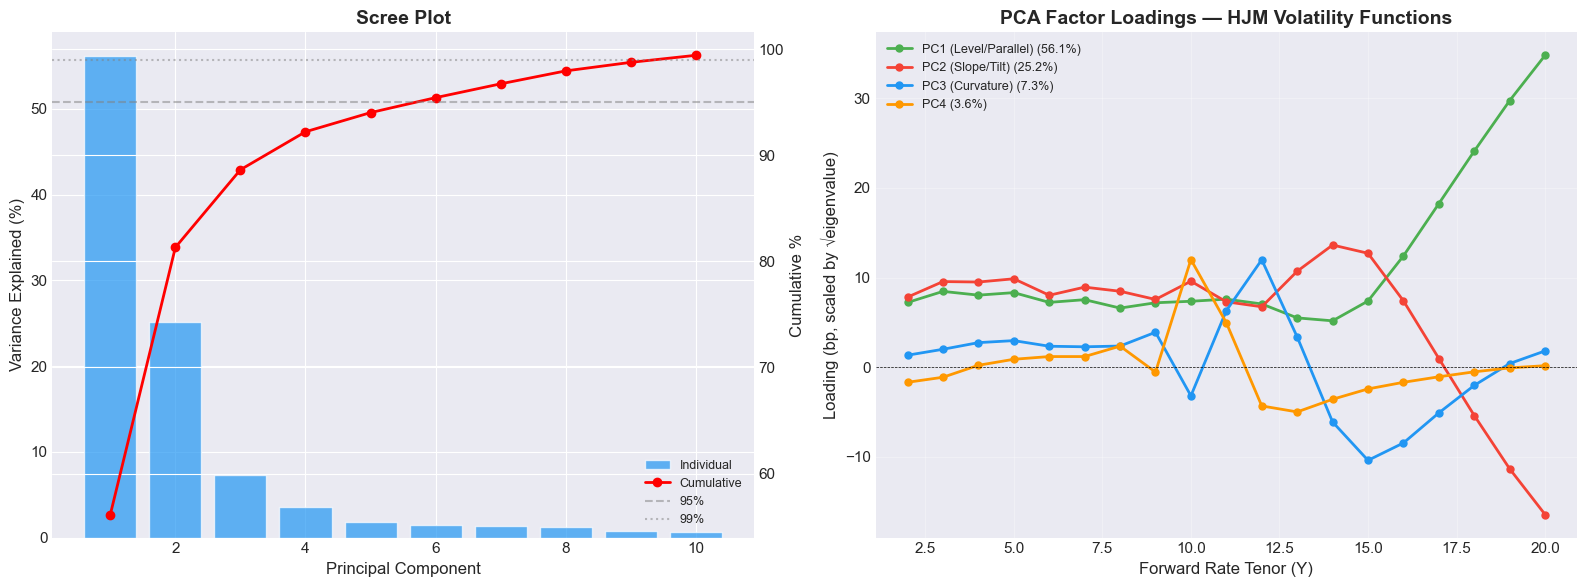

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, min(11, len(eigenvalues)+1)), var_explained[:10],
            color='#2196F3', alpha=0.7, edgecolor='white', label='Individual')
ax2 = axes[0].twinx()
ax2.plot(range(1, min(11, len(eigenvalues)+1)), cum_var[:10],
         'ro-', linewidth=2, markersize=6, label='Cumulative')
ax2.axhline(y=95, color='gray', linestyle='--', alpha=0.5, label='95%')
ax2.axhline(y=99, color='gray', linestyle=':', alpha=0.5, label='99%')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
ax2.set_ylabel('Cumulative %')
axes[0].set_title('Scree Plot', fontweight='bold')
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# Factor loadings (first 3 PCs)
tenor_years = np.array([t + 1 for t in use_tenors])
colors_pc = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']
labels_pc = ['PC1 (Level/Parallel)', 'PC2 (Slope/Tilt)', 'PC3 (Curvature)', 'PC4']

for k in range(min(4, len(eigenvalues))):
    loading = eigenvectors[:, k] * np.sqrt(eigenvalues[k]) * 100  # scale to bp
    # Ensure PC1 is positive (convention)
    if k == 0 and np.mean(loading) < 0:
        loading = -loading
    # Ensure PC2 is positive at short end
    if k == 1 and loading[0] < 0:
        loading = -loading
    axes[1].plot(tenor_years, loading, 'o-', color=colors_pc[k],
                 linewidth=2, markersize=5, label=f'{labels_pc[k]} ({var_explained[k]:.1f}%)')

axes[1].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('Forward Rate Tenor (Y)')
axes[1].set_ylabel('Loading (bp, scaled by √eigenvalue)')
axes[1].set_title('PCA Factor Loadings — HJM Volatility Functions', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Parametric Volatility Functions

We fit smooth parametric functions to the PCA loadings. Common choices:

- **PC1** (level): $\sigma_1(\tau) = a_1$ (constant — parallel shift)
- **PC2** (slope): $\sigma_2(\tau) = a_2 \cdot e^{-b_2 \tau}$ (exponentially decaying)
- **PC3** (curvature): $\sigma_3(\tau) = a_3 \cdot \tau \cdot e^{-b_3 \tau}$ (hump-shaped)

These ensure the HJM drift integral is analytically tractable.

PC1 (constant): σ₁ = 11.571 bp
PC2 (exponential): σ₂(τ) = 14.471bp × exp(-0.0903τ)
PC3 (hump): σ₃(τ) = 2.375bp × τ × exp(-0.3064τ)


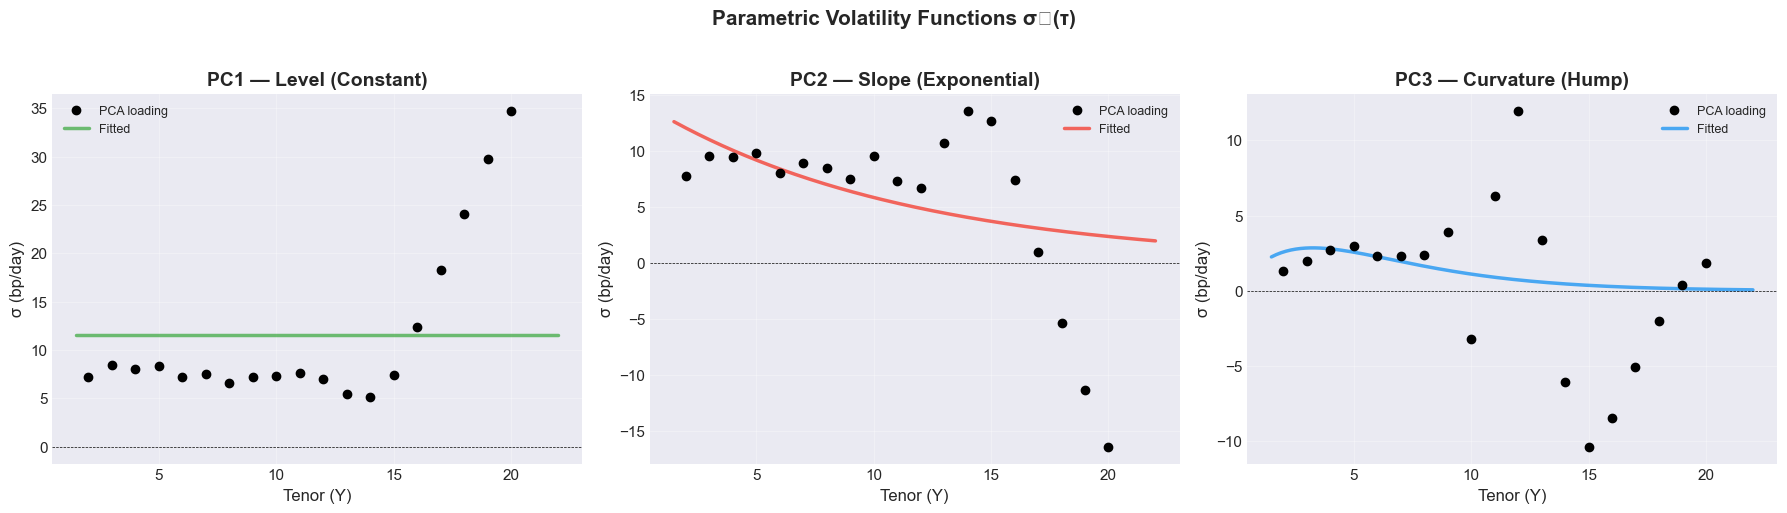

In [10]:
# Define parametric volatility functions
def vol_constant(tau, a):
    return np.full_like(tau, a, dtype=float)

def vol_exponential(tau, a, b):
    return a * np.exp(-b * tau)

def vol_hump(tau, a, b):
    return a * tau * np.exp(-b * tau)

# Extract raw (unscaled) PCA loadings, sign-corrected
raw_loadings = []
for k in range(3):
    loading = eigenvectors[:, k] * np.sqrt(eigenvalues[k])
    if k == 0 and np.mean(loading) < 0:
        loading = -loading
    if k == 1 and loading[0] < 0:
        loading = -loading
    raw_loadings.append(loading)

tau_fit = tenor_years.astype(float)

# Fit PC1: constant
mean_pc1 = np.mean(np.abs(raw_loadings[0]))
sigma1_params = [mean_pc1]
sigma1_fitted = vol_constant(tau_fit, *sigma1_params)
print(f"PC1 (constant): σ₁ = {mean_pc1*100:.3f} bp")

# Fit PC2: exponential decay
try:
    popt2, _ = curve_fit(vol_exponential, tau_fit, raw_loadings[1],
                         p0=[raw_loadings[1][0], 0.1], maxfev=10000)
    sigma2_params = popt2.tolist()
    sigma2_fitted = vol_exponential(tau_fit, *popt2)
    print(f"PC2 (exponential): σ₂(τ) = {popt2[0]*100:.3f}bp × exp(-{popt2[1]:.4f}τ)")
except:
    sigma2_params = [raw_loadings[1][0], 0.1]
    sigma2_fitted = vol_exponential(tau_fit, *sigma2_params)
    print(f"PC2 (exponential): fallback params")

# Fit PC3: hump
try:
    popt3, _ = curve_fit(vol_hump, tau_fit, raw_loadings[2],
                         p0=[np.max(np.abs(raw_loadings[2])) * 0.5, 0.2], maxfev=10000)
    sigma3_params = popt3.tolist()
    sigma3_fitted = vol_hump(tau_fit, *popt3)
    print(f"PC3 (hump): σ₃(τ) = {popt3[0]*100:.3f}bp × τ × exp(-{popt3[1]:.4f}τ)")
except:
    sigma3_params = [0.001, 0.2]
    sigma3_fitted = vol_hump(tau_fit, *sigma3_params)
    print(f"PC3 (hump): fallback params")

# Plot fitted vs empirical
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['PC1 — Level (Constant)', 'PC2 — Slope (Exponential)', 'PC3 — Curvature (Hump)']
raw = raw_loadings
fitted = [sigma1_fitted, sigma2_fitted, sigma3_fitted]
colors_fit = ['#4CAF50', '#F44336', '#2196F3']

tau_smooth = np.linspace(1.5, 22, 200)
smooth_fns = [
    vol_constant(tau_smooth, *sigma1_params),
    vol_exponential(tau_smooth, *sigma2_params),
    vol_hump(tau_smooth, *sigma3_params),
]

for k in range(3):
    axes[k].plot(tau_fit, raw[k] * 100, 'ko', markersize=6, label='PCA loading', zorder=5)
    axes[k].plot(tau_smooth, smooth_fns[k] * 100, '-', color=colors_fit[k],
                 linewidth=2.5, label='Fitted', alpha=0.8)
    axes[k].set_title(titles[k], fontweight='bold')
    axes[k].set_xlabel('Tenor (Y)')
    axes[k].set_ylabel('σ (bp/day)')
    axes[k].legend(fontsize=9)
    axes[k].grid(True, alpha=0.3)
    axes[k].axhline(y=0, color='black', linewidth=0.5, linestyle='--')

plt.suptitle('Parametric Volatility Functions σₖ(τ)', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 6. HJM No-Arbitrage Drift

Under the risk-neutral measure, the HJM drift restriction requires:

$$\alpha_k(t,T) = \sigma_k(t,T) \int_t^T \sigma_k(t,s)\,ds$$

We compute this numerically for each volatility factor, then sum across factors to get the total drift.

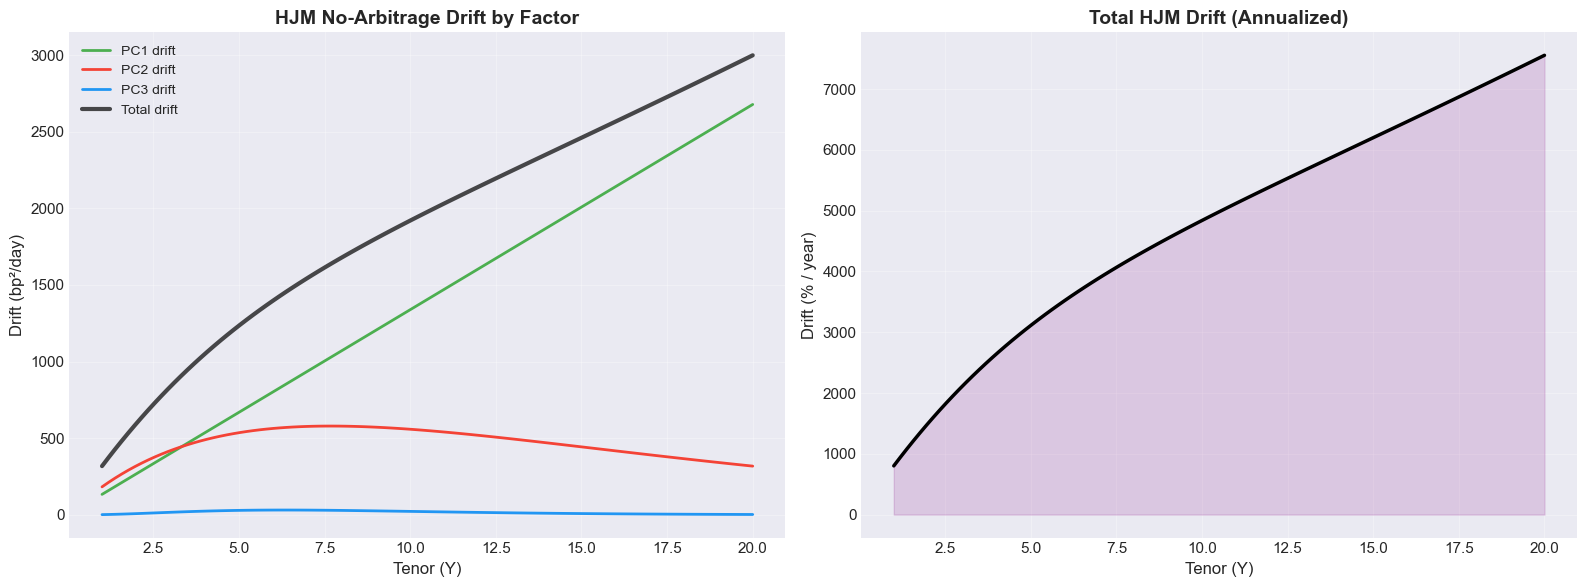

The HJM drift is always positive — forward rates drift upward under the
risk-neutral measure. This is the 'convexity adjustment' built into HJM.

Drift at selected tenors (annualized, in bp):
   2Y: 147418.00 bp/year
   5Y: 312501.37 bp/year
  10Y: 484427.53 bp/year
  15Y: 620268.54 bp/year
  20Y: 755536.48 bp/year


In [11]:
def hjm_drift_factor(sigma_fn, sigma_params, tau, dt_grid=0.01):
    """
    Compute the HJM no-arbitrage drift for one volatility factor.
    
    For forward rate at tenor tau:
      drift(tau) = sigma(tau) * integral_0^tau sigma(s) ds
      
    (We use the Musiela parameterisation where tau = T - t.)
    """
    drift = np.zeros_like(tau, dtype=float)
    for i, t in enumerate(tau):
        # Numerical integration of sigma(s) from 0 to t
        s_grid = np.linspace(0.001, t, max(int(t / dt_grid), 10))
        sigma_values = sigma_fn(s_grid, *sigma_params)
        integral = np.trapz(sigma_values, s_grid)
        drift[i] = sigma_fn(np.array([t]), *sigma_params)[0] * integral
    return drift


# Compute drift for each factor
tau_grid = np.linspace(1, 20, 100)

drift1 = hjm_drift_factor(vol_constant, sigma1_params, tau_grid)
drift2 = hjm_drift_factor(vol_exponential, sigma2_params, tau_grid)
drift3 = hjm_drift_factor(vol_hump, sigma3_params, tau_grid)
total_drift = drift1 + drift2 + drift3

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual drift contributions
axes[0].plot(tau_grid, drift1 * 1e4, '-', color='#4CAF50', linewidth=2, label='PC1 drift')
axes[0].plot(tau_grid, drift2 * 1e4, '-', color='#F44336', linewidth=2, label='PC2 drift')
axes[0].plot(tau_grid, drift3 * 1e4, '-', color='#2196F3', linewidth=2, label='PC3 drift')
axes[0].plot(tau_grid, total_drift * 1e4, 'k-', linewidth=3, label='Total drift', alpha=0.7)
axes[0].set_title('HJM No-Arbitrage Drift by Factor', fontweight='bold')
axes[0].set_xlabel('Tenor (Y)')
axes[0].set_ylabel('Drift (bp²/day)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Drift in annualized terms
axes[1].plot(tau_grid, total_drift * 252 * 100, 'k-', linewidth=2.5)
axes[1].fill_between(tau_grid, 0, total_drift * 252 * 100, alpha=0.15, color='purple')
axes[1].set_title('Total HJM Drift (Annualized)', fontweight='bold')
axes[1].set_xlabel('Tenor (Y)')
axes[1].set_ylabel('Drift (% / year)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"The HJM drift is always positive — forward rates drift upward under the")
print(f"risk-neutral measure. This is the 'convexity adjustment' built into HJM.")
print(f"\nDrift at selected tenors (annualized, in bp):")
for T in [2, 5, 10, 15, 20]:
    idx = np.argmin(np.abs(tau_grid - T))
    print(f"  {T:>2d}Y: {total_drift[idx] * 252 * 10000:.2f} bp/year")

## 7. Monte Carlo Simulation

Simulate forward rate curve paths using the calibrated HJM model.

In the discretized Musiela parameterisation:

$$f(t+\Delta t, \tau) = f(t, \tau+\Delta t) + \alpha(\tau)\Delta t + \sum_{k=1}^{K} \sigma_k(\tau) \sqrt{\Delta t}\, Z_k$$

where $Z_k \sim N(0,1)$ are independent standard normals.

In [12]:
def simulate_hjm(f0, tau_grid, n_steps, dt, sigma_fns, sigma_params_list,
                 n_paths=1000, n_factors=3):
    """
    Simulate forward rate curve paths under the HJM model.
    
    f0: initial forward curve, array of shape (n_tenors,)
    tau_grid: tenor grid, array of shape (n_tenors,)
    n_steps: number of time steps
    dt: time step (in years, e.g. 1/252 for daily)
    sigma_fns: list of volatility functions
    sigma_params_list: list of parameter tuples for each vol function
    n_paths: number of Monte Carlo paths
    n_factors: number of factors to use
    """
    n_tenors = len(tau_grid)
    sqrt_dt = np.sqrt(dt)
    
    # Pre-compute volatilities and drifts on the tenor grid
    sigmas = np.zeros((n_factors, n_tenors))
    for k in range(n_factors):
        sigmas[k] = sigma_fns[k](tau_grid, *sigma_params_list[k])
    
    # HJM drift for each tenor
    drift = np.zeros(n_tenors)
    for k in range(n_factors):
        drift += hjm_drift_factor(sigma_fns[k], sigma_params_list[k], tau_grid)
    
    # Initialize paths
    paths = np.zeros((n_paths, n_steps + 1, n_tenors))
    paths[:, 0, :] = f0
    
    # Simulate
    for t in range(n_steps):
        Z = np.random.randn(n_paths, n_factors)
        
        # Drift contribution
        df = drift * dt
        
        # Diffusion contribution
        for k in range(n_factors):
            df = df + np.outer(Z[:, k], sigmas[k]) * sqrt_dt
        
        # Musiela drift (shift the curve by dt along tenor axis)
        # Approximate: f(t+dt, tau) ≈ f(t, tau) + df/dtau * dt + stochastic
        # For simplicity, we just evolve in place (common discrete HJM approach)
        paths[:, t + 1, :] = paths[:, t, :] + df
    
    return paths


# Set up simulation
# Initial forward curve from latest data
f0 = np.interp(tau_grid, tenor_years.astype(float), fwd_matrix[-1, use_tenors])
# Replace any NaN
nan_mask = np.isnan(f0)
if nan_mask.any():
    f0[nan_mask] = np.interp(tau_grid[nan_mask], tau_grid[~nan_mask], f0[~nan_mask])

sigma_fns = [vol_constant, vol_exponential, vol_hump]
sigma_params_all = [sigma1_params, sigma2_params, sigma3_params]

# Simulation parameters
n_sim_paths = 2000
n_sim_steps = 252  # 1 year of daily steps
dt_sim = 1.0 / 252

np.random.seed(42)
print(f"Simulating {n_sim_paths:,} paths × {n_sim_steps} steps ({n_sim_steps/252:.1f} year)...")
paths = simulate_hjm(f0, tau_grid, n_sim_steps, dt_sim,
                     sigma_fns, sigma_params_all, n_paths=n_sim_paths, n_factors=3)
print(f"Done! Path tensor shape: {paths.shape} (paths × steps × tenors)")

Simulating 2,000 paths × 252 steps (1.0 year)...


Done! Path tensor shape: (2000, 253, 100) (paths × steps × tenors)


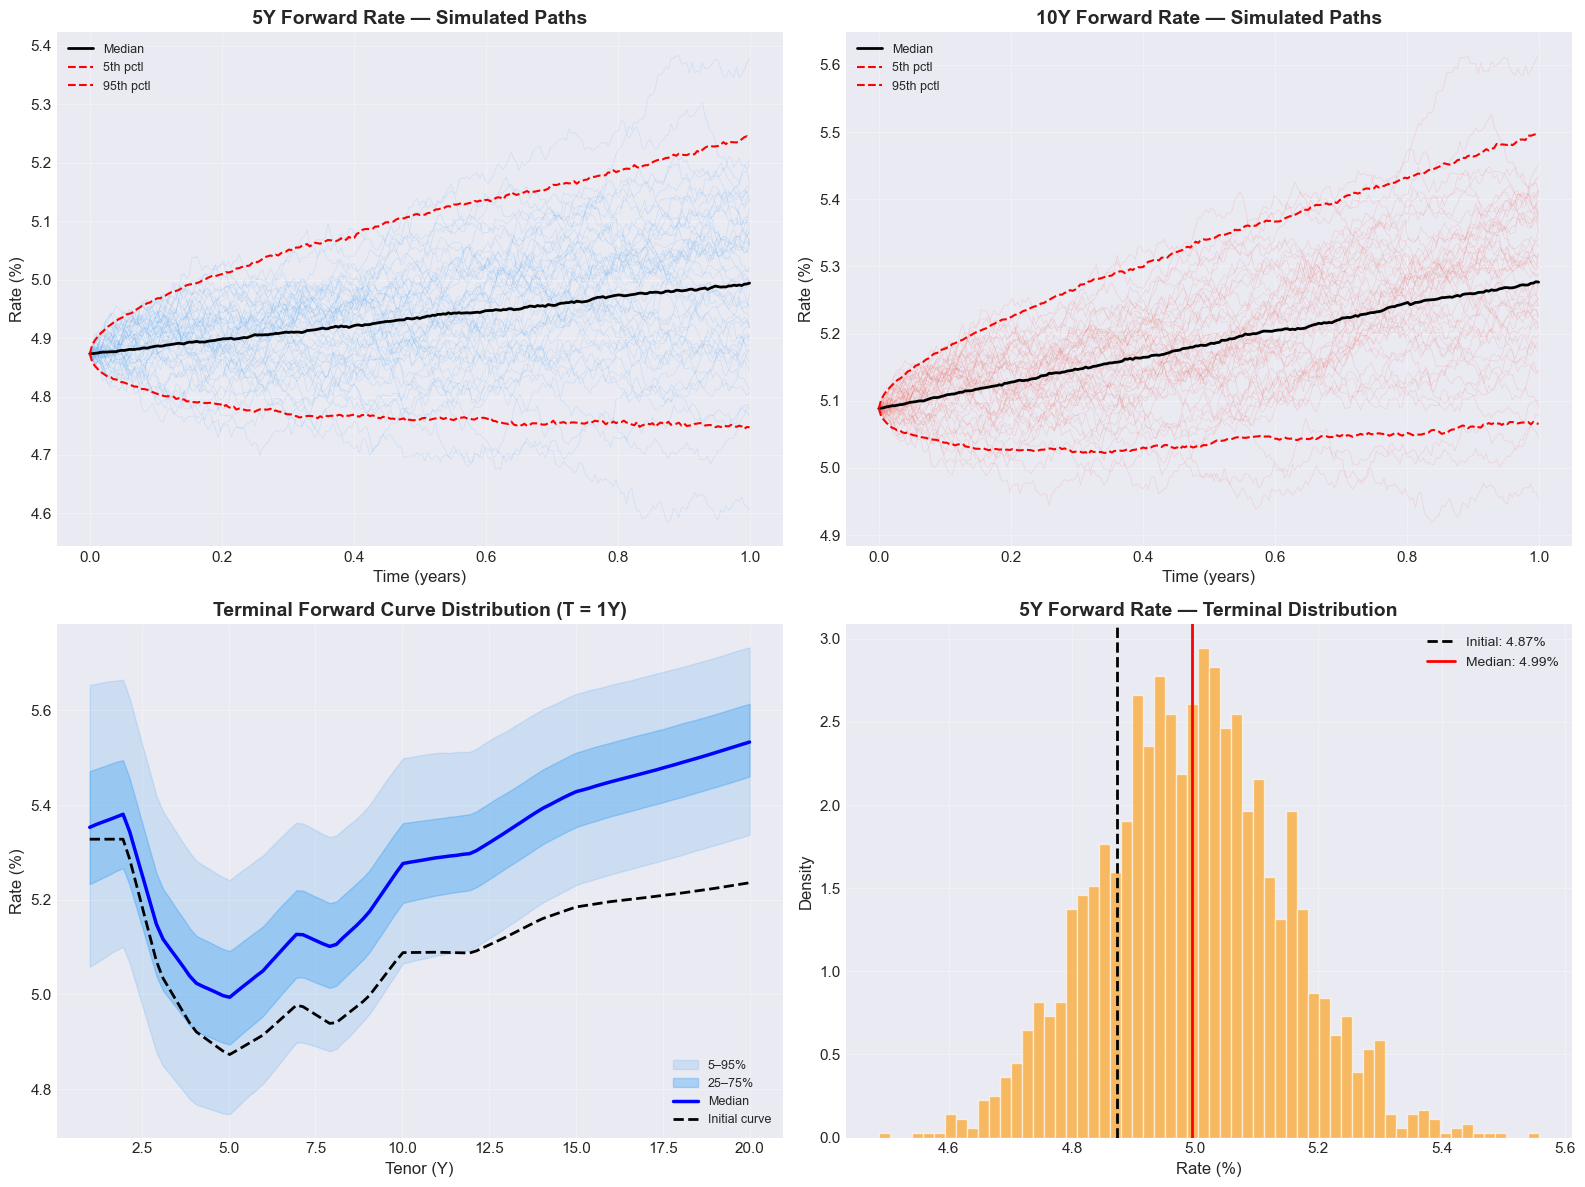

In [13]:
# Visualize simulated paths
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Sample paths for the 5Y forward rate
tenor_5y_idx = np.argmin(np.abs(tau_grid - 5))
time_axis = np.arange(n_sim_steps + 1) / 252  # in years

axes[0, 0].plot(time_axis, paths[:50, :, tenor_5y_idx].T, alpha=0.15, color='#2196F3', linewidth=0.5)
axes[0, 0].plot(time_axis, np.median(paths[:, :, tenor_5y_idx], axis=0), 'k-', linewidth=2, label='Median')
axes[0, 0].plot(time_axis, np.percentile(paths[:, :, tenor_5y_idx], 5, axis=0),
                'r--', linewidth=1.5, label='5th pctl')
axes[0, 0].plot(time_axis, np.percentile(paths[:, :, tenor_5y_idx], 95, axis=0),
                'r--', linewidth=1.5, label='95th pctl')
axes[0, 0].set_title('5Y Forward Rate — Simulated Paths', fontweight='bold')
axes[0, 0].set_xlabel('Time (years)')
axes[0, 0].set_ylabel('Rate (%)')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Top-right: Sample paths for the 10Y forward rate
tenor_10y_idx = np.argmin(np.abs(tau_grid - 10))
axes[0, 1].plot(time_axis, paths[:50, :, tenor_10y_idx].T, alpha=0.15, color='#F44336', linewidth=0.5)
axes[0, 1].plot(time_axis, np.median(paths[:, :, tenor_10y_idx], axis=0), 'k-', linewidth=2, label='Median')
axes[0, 1].plot(time_axis, np.percentile(paths[:, :, tenor_10y_idx], 5, axis=0),
                'r--', linewidth=1.5, label='5th pctl')
axes[0, 1].plot(time_axis, np.percentile(paths[:, :, tenor_10y_idx], 95, axis=0),
                'r--', linewidth=1.5, label='95th pctl')
axes[0, 1].set_title('10Y Forward Rate — Simulated Paths', fontweight='bold')
axes[0, 1].set_xlabel('Time (years)')
axes[0, 1].set_ylabel('Rate (%)')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: Terminal forward curve distribution
terminal_curves = paths[:, -1, :]
median_curve = np.median(terminal_curves, axis=0)
pctl_5 = np.percentile(terminal_curves, 5, axis=0)
pctl_25 = np.percentile(terminal_curves, 25, axis=0)
pctl_75 = np.percentile(terminal_curves, 75, axis=0)
pctl_95 = np.percentile(terminal_curves, 95, axis=0)

axes[1, 0].fill_between(tau_grid, pctl_5, pctl_95, alpha=0.15, color='#2196F3', label='5–95%')
axes[1, 0].fill_between(tau_grid, pctl_25, pctl_75, alpha=0.3, color='#2196F3', label='25–75%')
axes[1, 0].plot(tau_grid, median_curve, 'b-', linewidth=2.5, label='Median')
axes[1, 0].plot(tau_grid, f0, 'k--', linewidth=2, label='Initial curve')
axes[1, 0].set_title(f'Terminal Forward Curve Distribution (T = {n_sim_steps/252:.0f}Y)', fontweight='bold')
axes[1, 0].set_xlabel('Tenor (Y)')
axes[1, 0].set_ylabel('Rate (%)')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: Distribution of 5Y rate at terminal time
terminal_5y = paths[:, -1, tenor_5y_idx]
axes[1, 1].hist(terminal_5y, bins=60, density=True, alpha=0.6, color='#FF9800', edgecolor='white')
axes[1, 1].axvline(x=f0[tenor_5y_idx], color='black', linewidth=2, linestyle='--',
                   label=f'Initial: {f0[tenor_5y_idx]:.2f}%')
axes[1, 1].axvline(x=np.median(terminal_5y), color='red', linewidth=2,
                   label=f'Median: {np.median(terminal_5y):.2f}%')
axes[1, 1].set_title('5Y Forward Rate — Terminal Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Rate (%)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Model Validation

Verify that the simulated paths reproduce key statistical properties of the historical data.

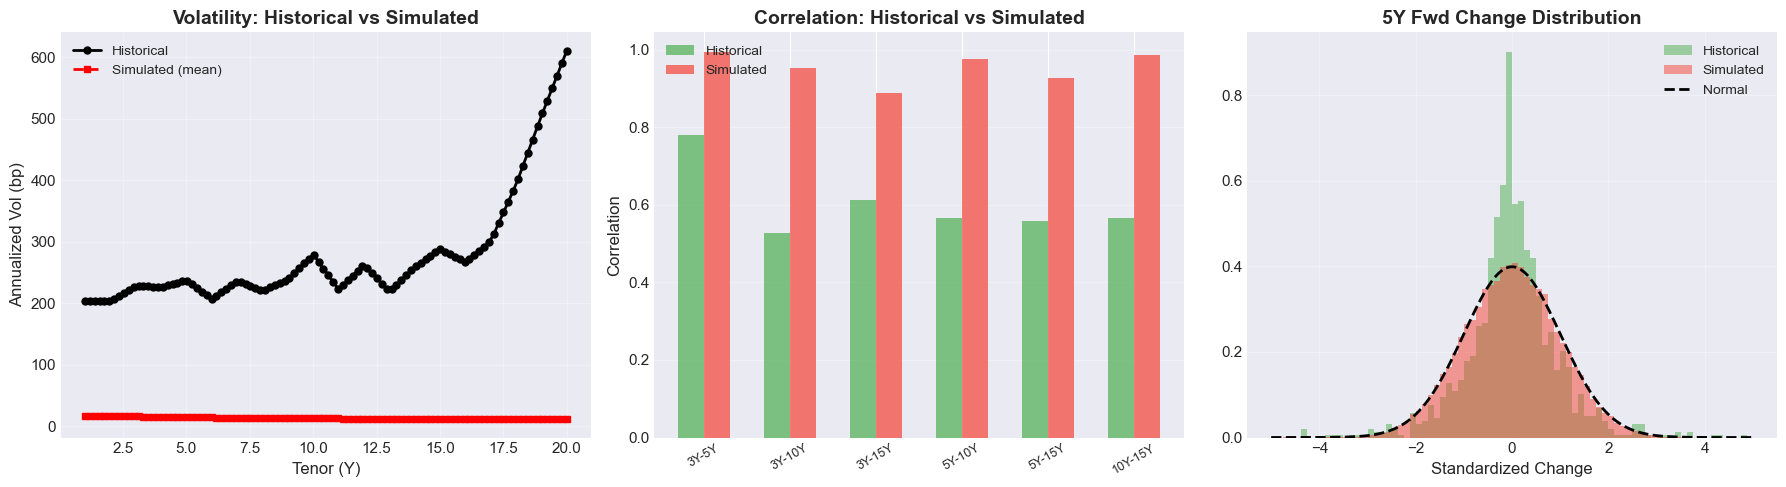

Note: The Gaussian HJM model produces normally distributed changes.
Historical data has fat tails — a limitation of the standard HJM model.
Extensions: jump-diffusion HJM, stochastic volatility, or regime-switching.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Volatility comparison: simulated vs historical
sim_changes = np.diff(paths, axis=1)  # (n_paths, n_steps, n_tenors)
sim_vol = np.std(sim_changes, axis=1).mean(axis=0) * np.sqrt(252) * 100  # annualized bp
hist_vol_interp = np.interp(tau_grid, tenor_years.astype(float),
                            np.std(fwd_changes_clean, axis=0)) * np.sqrt(252) * 100

axes[0].plot(tau_grid, hist_vol_interp, 'ko-', linewidth=2, markersize=5, label='Historical')
axes[0].plot(tau_grid, sim_vol, 'rs--', linewidth=2, markersize=5, label='Simulated (mean)')
axes[0].set_title('Volatility: Historical vs Simulated', fontweight='bold')
axes[0].set_xlabel('Tenor (Y)')
axes[0].set_ylabel('Annualized Vol (bp)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. Correlation comparison for selected tenor pairs
tenor_indices = [np.argmin(np.abs(tau_grid - t)) for t in [3, 5, 10, 15]]
tenor_names = ['3Y', '5Y', '10Y', '15Y']

# Historical correlations (interpolated to match tau_grid)
hist_changes_interp = np.zeros((fwd_changes_clean.shape[0], len(tau_grid)))
for i in range(len(fwd_changes_clean)):
    hist_changes_interp[i, :] = np.interp(tau_grid, tenor_years.astype(float), fwd_changes_clean[i])

sim_path0_changes = sim_changes[0]  # use single long path as representative

pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
pair_labels = [f'{tenor_names[a]}-{tenor_names[b]}' for a,b in pairs]
hist_corrs = []
sim_corrs = []

for a, b in pairs:
    ia, ib = tenor_indices[a], tenor_indices[b]
    hc = np.corrcoef(hist_changes_interp[:, ia], hist_changes_interp[:, ib])[0, 1]
    # For simulated, average across paths
    sc = np.mean([np.corrcoef(sim_changes[p, :, ia], sim_changes[p, :, ib])[0, 1]
                   for p in range(min(200, n_sim_paths))])
    hist_corrs.append(hc)
    sim_corrs.append(sc)

x = np.arange(len(pairs))
axes[1].bar(x - 0.15, hist_corrs, 0.3, label='Historical', color='#4CAF50', alpha=0.7)
axes[1].bar(x + 0.15, sim_corrs, 0.3, label='Simulated', color='#F44336', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(pair_labels, rotation=30, fontsize=9)
axes[1].set_title('Correlation: Historical vs Simulated', fontweight='bold')
axes[1].set_ylabel('Correlation')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# 3. QQ plot for 5Y forward changes
from scipy.stats import probplot
sim_5y_changes = sim_changes[:, :, tenor_5y_idx].flatten()
hist_5y_idx = np.argmin(np.abs(tenor_years - 5))
hist_5y_changes = fwd_changes_clean[:, hist_5y_idx]

# Standardize both
sim_std = (sim_5y_changes - sim_5y_changes.mean()) / sim_5y_changes.std()
hist_std = (hist_5y_changes - hist_5y_changes.mean()) / hist_5y_changes.std()

axes[2].hist(hist_std, bins=80, density=True, alpha=0.5, color='#4CAF50', label='Historical', range=(-5, 5))
axes[2].hist(sim_std[::10], bins=80, density=True, alpha=0.5, color='#F44336', label='Simulated', range=(-5, 5))
x_norm = np.linspace(-5, 5, 200)
from scipy.stats import norm
axes[2].plot(x_norm, norm.pdf(x_norm), 'k--', linewidth=2, label='Normal')
axes[2].set_title('5Y Fwd Change Distribution', fontweight='bold')
axes[2].set_xlabel('Standardized Change')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: The Gaussian HJM model produces normally distributed changes.")
print("Historical data has fat tails — a limitation of the standard HJM model.")
print("Extensions: jump-diffusion HJM, stochastic volatility, or regime-switching.")

## 9. Application: Swap Valuation via Monte Carlo

Price a **5-year payer interest rate swap** (pay fixed, receive floating) using our simulated HJM paths.

The value of a payer swap at inception:

$$V = \sum_{i=1}^{n} P(0,T_i) \cdot \Delta \cdot \left[\mathbb{E}^{T_i}[L(T_{i-1}, T_i)] - K\right]$$

where $K$ is the fixed rate. At-the-money means $K = $ par swap rate.

Current 5Y ATM swap rate: 4.130%


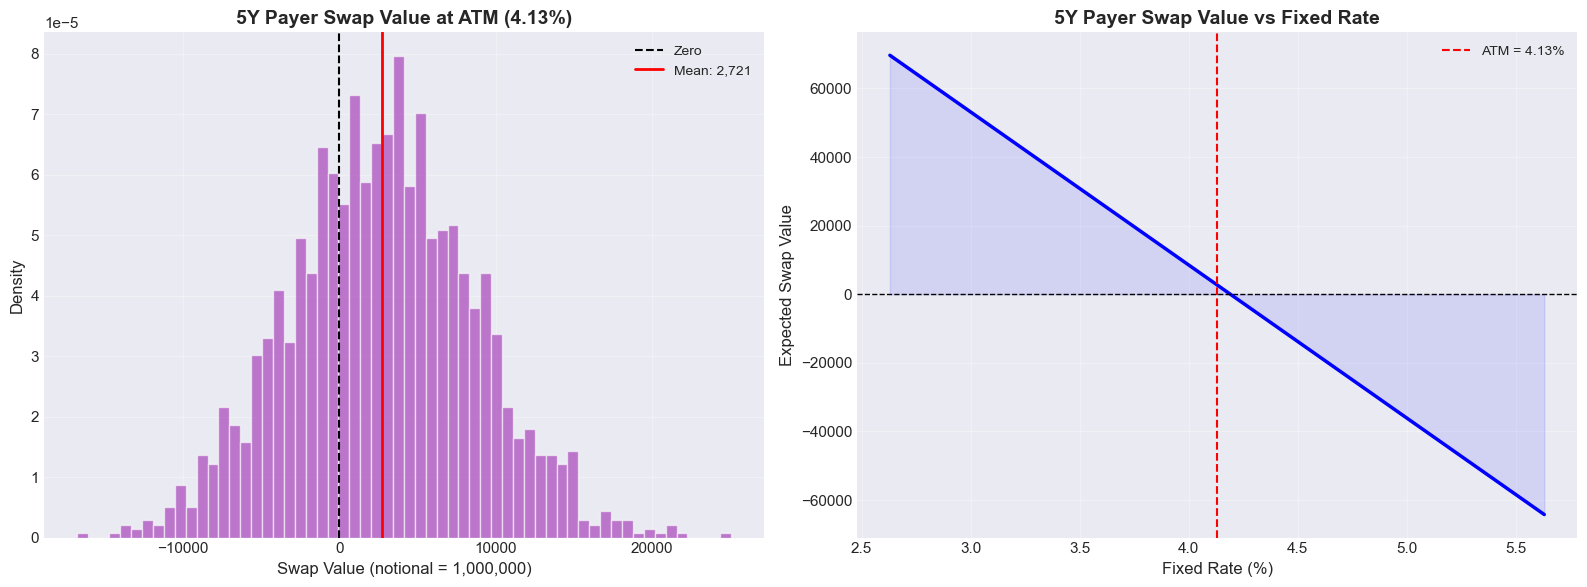


5Y Payer Swap MC Results (Notional = 1,000,000):
  ATM rate:    4.130%
  Mean value:      2,720.57
  Std dev:         5,924.09
  5th pctl:       -7,171.24
  95th pctl:      12,588.32
  P(loss):     32.6%


In [15]:
def fwd_to_discount(fwd_curve, tau_grid):
    """
    Convert a forward rate curve to discount factors.
    P(0, T) = exp(-integral_0^T f(0,s) ds)
    """
    disc = np.zeros(len(tau_grid))
    for i in range(len(tau_grid)):
        # Integrate forward rates from 0 to tau_grid[i]
        mask = tau_grid <= tau_grid[i]
        if mask.sum() >= 2:
            disc[i] = np.exp(-np.trapz(fwd_curve[mask] / 100, tau_grid[mask]))
        else:
            disc[i] = np.exp(-fwd_curve[0] / 100 * tau_grid[i])
    return disc


def price_swap_from_fwd(fwd_curve, tau_grid, swap_tenor, fixed_rate, notional=1e6):
    """
    Price a payer swap (pay fixed, receive floating) from a forward curve.
    Assumes annual payments.
    """
    disc = fwd_to_discount(fwd_curve, tau_grid)
    
    payment_times = np.arange(1, swap_tenor + 1, dtype=float)
    disc_at_payments = np.interp(payment_times, tau_grid, disc)
    
    # Floating leg PV = P(0,0) - P(0,T_n) = 1 - P(0,T_n)
    float_pv = (1.0 - disc_at_payments[-1]) * notional
    
    # Fixed leg PV = K * sum P(0,T_i) * delta
    fixed_pv = fixed_rate / 100 * np.sum(disc_at_payments) * notional
    
    # Payer swap value = Float PV - Fixed PV
    return float_pv - fixed_pv


# Price a 5Y ATM swap using MC
swap_tenor = 5
notional = 1_000_000

# ATM rate from the current curve
disc_current = fwd_to_discount(f0, tau_grid)
payment_times = np.arange(1, swap_tenor + 1, dtype=float)
disc_payments = np.interp(payment_times, tau_grid, disc_current)
atm_rate = (1 - disc_payments[-1]) / np.sum(disc_payments) * 100
print(f"Current 5Y ATM swap rate: {atm_rate:.3f}%")

# MC pricing: value the swap at t=0 using terminal forward curves
# For a forward-starting swap (starts at simulation horizon), use terminal curves
swap_values = []
for p in range(n_sim_paths):
    terminal_fwd = paths[p, -1, :]
    sv = price_swap_from_fwd(terminal_fwd, tau_grid, swap_tenor, atm_rate, notional)
    swap_values.append(sv)

swap_values = np.array(swap_values)

# Also compute for different strikes
strikes = np.linspace(atm_rate - 1.5, atm_rate + 1.5, 31)
swap_value_by_strike = []
for K in strikes:
    vals = []
    for p in range(n_sim_paths):
        terminal_fwd = paths[p, -1, :]
        sv = price_swap_from_fwd(terminal_fwd, tau_grid, swap_tenor, K, notional)
        vals.append(sv)
    swap_value_by_strike.append(np.mean(vals))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Swap value distribution at ATM
axes[0].hist(swap_values, bins=60, density=True, alpha=0.6, color='#9C27B0', edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=1.5, linestyle='--', label='Zero')
axes[0].axvline(x=np.mean(swap_values), color='red', linewidth=2,
                label=f'Mean: {np.mean(swap_values):,.0f}')
axes[0].set_title(f'{swap_tenor}Y Payer Swap Value at ATM ({atm_rate:.2f}%)', fontweight='bold')
axes[0].set_xlabel(f'Swap Value (notional = {notional:,.0f})')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Swap value vs strike
axes[1].plot(strikes, swap_value_by_strike, 'b-', linewidth=2.5)
axes[1].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[1].axvline(x=atm_rate, color='red', linewidth=1.5, linestyle='--',
                label=f'ATM = {atm_rate:.2f}%')
axes[1].fill_between(strikes, 0, swap_value_by_strike, alpha=0.1, color='blue')
axes[1].set_title(f'{swap_tenor}Y Payer Swap Value vs Fixed Rate', fontweight='bold')
axes[1].set_xlabel('Fixed Rate (%)')
axes[1].set_ylabel(f'Expected Swap Value')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n5Y Payer Swap MC Results (Notional = {notional:,.0f}):")
print(f"  ATM rate:    {atm_rate:.3f}%")
print(f"  Mean value:  {np.mean(swap_values):>12,.2f}")
print(f"  Std dev:     {np.std(swap_values):>12,.2f}")
print(f"  5th pctl:    {np.percentile(swap_values, 5):>12,.2f}")
print(f"  95th pctl:   {np.percentile(swap_values, 95):>12,.2f}")
print(f"  P(loss):     {(swap_values < 0).mean()*100:.1f}%")

## 10. Export Calibrated Model

In [16]:
import json

hjm_model = {
    'n_factors': 3,
    'lambda_optimal': float(LAM) if 'LAM' in dir() else None,
    'calibration_window': f"{df_calib['date of fixing'].min().date()} to {df_calib['date of fixing'].max().date()}",
    'n_calibration_days': int(len(df_calib)),
    'tenor_grid': tau_grid.tolist(),
    'initial_forward_curve': f0.tolist(),
    'pca': {
        'eigenvalues': eigenvalues[:5].tolist(),
        'variance_explained_pct': var_explained[:5].tolist(),
        'n_factors_95pct': int(n_factors_95),
    },
    'volatility_functions': {
        'PC1_type': 'constant',
        'PC1_params': sigma1_params,
        'PC2_type': 'exponential_decay',
        'PC2_params': sigma2_params,
        'PC3_type': 'hump',
        'PC3_params': sigma3_params,
    },
    'simulation': {
        'n_paths': n_sim_paths,
        'n_steps': n_sim_steps,
        'dt': dt_sim,
    }
}

with open('data/hjm_model_params.json', 'w') as f:
    json.dump(hjm_model, f, indent=2)
print("Saved data/hjm_model_params.json")

# Save forward rate matrix
fwd_df = pd.DataFrame(fwd_matrix, columns=[f'{i+1}Y_fwd' for i in range(max_tenor)])
fwd_df.insert(0, 'date', fwd_dates)
fwd_df.to_pickle('data/forward_rates.pkl')
print(f"Saved data/forward_rates.pkl ({len(fwd_df):,} rows)")

print(f"\n✅ HJM Model Summary:")
print(f"  Factors:       {3} (PCA explains {cum_var[2]:.1f}%)")
print(f"  σ₁ (level):    constant = {sigma1_params[0]*100:.3f} bp/day")
print(f"  σ₂ (slope):    {sigma2_params[0]*100:.3f}bp × exp(-{sigma2_params[1]:.3f}τ)")
print(f"  σ₃ (curve):    {sigma3_params[0]*100:.3f}bp × τ × exp(-{sigma3_params[1]:.3f}τ)")
print(f"  Initial curve: {f0.min():.2f}% – {f0.max():.2f}%")

Saved data/hjm_model_params.json
Saved data/forward_rates.pkl (1,263 rows)

✅ HJM Model Summary:
  Factors:       3 (PCA explains 88.6%)
  σ₁ (level):    constant = 11.571 bp/day
  σ₂ (slope):    14.471bp × exp(-0.090τ)
  σ₃ (curve):    2.375bp × τ × exp(-0.306τ)
  Initial curve: 4.87% – 5.33%


## 📋 Summary

### What we built:
1. **Bootstrapping pipeline** — BIRS swap rates → zero rates → forward rates
2. **Forward rate surface** — daily forward curves across 5 years of history
3. **PCA decomposition** — extracted dominant volatility factors from forward rate changes
4. **Parametric volatility functions** — fitted level/slope/curvature forms to PCA loadings
5. **HJM drift restriction** — computed the no-arbitrage drift from the volatility structure
6. **Monte Carlo engine** — simulated 2,000 forward rate paths over 1 year
7. **Model validation** — compared simulated vs historical volatility and correlation
8. **Swap pricing** — valued a 5Y payer swap using the MC paths

### Key outputs:
- `hjm_model_params.json` — full model specification
- `forward_rates.pkl` — daily forward rate curves

### Limitations & extensions:
| Limitation | Extension |
|:-----------|:----------|
| Gaussian (no fat tails) | Jump-diffusion HJM, or Lévy-driven HJM |
| Constant volatility fns | Time-varying / stochastic volatility |
| No negative rate floor | Shifted log-normal or SABR-HJM |
| Simple bootstrap | Dual-curve bootstrapping (OIS discounting) |
| No swaption calibration | Calibrate σ(t,T) to swaption implied vols |

---
*References:*
- *Heath, D., Jarrow, R., & Morton, A. (1992). "Bond Pricing and the Term Structure of Interest Rates: A New Methodology for Contingent Claims Valuation." Econometrica.*
- *Rebonato, R. (1998). "Interest Rate Option Models." Wiley.*